In [ ]:
#Problem statement:
#Our client is an Insurance company that has provided Health Insurance to its customers now they 
#need your help in building a model to predict whether the policyholders (customers) from 
#the past year will also be interested in Vehicle Insurance provided by the company.
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib
%matplotlib inline

In [2]:
raw_train_df=pd.read_csv('train.csv')
raw_test_df=pd.read_csv('test.csv')

In [3]:
raw_train_df

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0
...,...,...,...,...,...,...,...,...,...,...,...,...
381104,381105,Male,74,1,26.0,1,1-2 Year,No,30170.0,26.0,88,0
381105,381106,Male,30,1,37.0,1,< 1 Year,No,40016.0,152.0,131,0
381106,381107,Male,21,1,30.0,1,< 1 Year,No,35118.0,160.0,161,0
381107,381108,Female,68,1,14.0,0,> 2 Years,Yes,44617.0,124.0,74,0


In [4]:
raw_test_df

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage
0,381110,Male,25,1,11.0,1,< 1 Year,No,35786.0,152.0,53
1,381111,Male,40,1,28.0,0,1-2 Year,Yes,33762.0,7.0,111
2,381112,Male,47,1,28.0,0,1-2 Year,Yes,40050.0,124.0,199
3,381113,Male,24,1,27.0,1,< 1 Year,Yes,37356.0,152.0,187
4,381114,Male,27,1,28.0,1,< 1 Year,No,59097.0,152.0,297
...,...,...,...,...,...,...,...,...,...,...,...
127032,508142,Female,26,1,37.0,1,< 1 Year,No,30867.0,152.0,56
127033,508143,Female,38,1,28.0,0,1-2 Year,Yes,28700.0,122.0,165
127034,508144,Male,21,1,46.0,1,< 1 Year,No,29802.0,152.0,74
127035,508145,Male,71,1,28.0,1,1-2 Year,No,62875.0,26.0,265


In [5]:
raw_train_df.isna().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [6]:
raw_train_df.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [7]:
raw_test_df.isna().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
dtype: int64

In [8]:
raw_test_df.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
dtype: int64

In [9]:
raw_train_df.describe()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


In [10]:
raw_test_df.describe(include = ['object'])

,Gender,Vehicle_Age,Vehicle_Damage
count,127037,127037,127037
unique,2,3,2
top,Male,1-2 Year,Yes
freq,68236,66699,63835


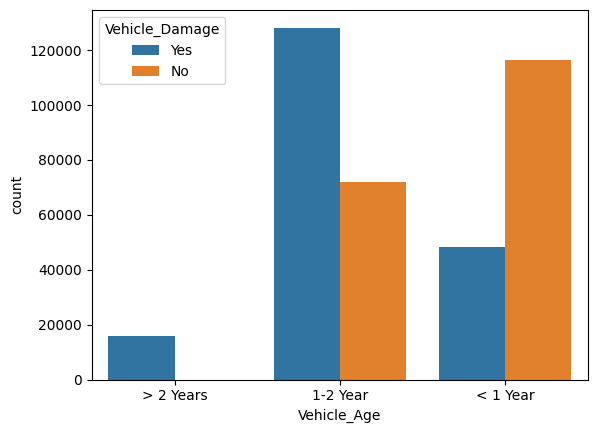

In [11]:
sns.countplot(data=raw_train_df,x='Vehicle_Age',hue='Vehicle_Damage');

In [12]:
raw_train_df.drop("id", inplace=True, axis=1)
raw_test_df.drop("id",inplace=True, axis=1)
#Categorical data into numeric data with raw_train_df
raw_train_df['Gender']=raw_train_df['Gender'].replace({'Male':1,'Female':0})
raw_train_df.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,1,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,1,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,1,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,0,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [13]:
raw_train_df['Vehicle_Damage'].replace({'Yes':1,'No':0}, inplace=True)
raw_train_df['Vehicle_Age'].replace({'< 1 Year':1,'1-2 Year':2,'> 2 Years':3}, inplace=True)
raw_train_df.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,44,1,28.0,0,3,1,40454.0,26.0,217,1
1,1,76,1,3.0,0,2,0,33536.0,26.0,183,0
2,1,47,1,28.0,0,3,1,38294.0,26.0,27,1
3,1,21,1,11.0,1,1,0,28619.0,152.0,203,0
4,0,29,1,41.0,1,1,0,27496.0,152.0,39,0


In [14]:
train_df=raw_train_df

In [15]:
hig_corr = train_df.corr()
hig_corr_features = hig_corr.index[abs(hig_corr["Response"]) >= 0.2]
hig_corr_features

Index(['Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Response'], dtype='object')

In [16]:
raw_test_df['Gender']=raw_test_df['Gender'].replace({'Male':1,'Female':0})
raw_test_df['Vehicle_Damage'].replace({'Yes':1,'No':0}, inplace=True)
raw_test_df['Vehicle_Age'].replace({'< 1 Year':1,'1-2 Year':2,'> 2 Years':3}, inplace=True)

In [17]:
test_df=raw_test_df
test_df

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage
0,1,25,1,11.0,1,1,0,35786.0,152.0,53
1,1,40,1,28.0,0,2,1,33762.0,7.0,111
2,1,47,1,28.0,0,2,1,40050.0,124.0,199
3,1,24,1,27.0,1,1,1,37356.0,152.0,187
4,1,27,1,28.0,1,1,0,59097.0,152.0,297
...,...,...,...,...,...,...,...,...,...,...
127032,0,26,1,37.0,1,1,0,30867.0,152.0,56
127033,0,38,1,28.0,0,2,1,28700.0,122.0,165
127034,1,21,1,46.0,1,1,0,29802.0,152.0,74
127035,1,71,1,28.0,1,2,0,62875.0,26.0,265


In [18]:
numeric_cols=['Age','Region_Code','Annual_Premium','Policy_Sales_Channel','Vintage']
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaler.fit(train_df[numeric_cols])

MinMaxScaler()

In [19]:
train_df[numeric_cols]=scaler.transform(train_df[numeric_cols])
test_df[numeric_cols]=scaler.transform(test_df[numeric_cols])
train_df.describe().loc[['min', 'max']]

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
min,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,3.0,1.0,1.0,1.0,1.0,1.0


In [20]:
test_df.describe().loc[['min', 'max']]

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage
min,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.000000,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,3.0,1.0,0.873268,1.0,1.0


In [21]:
input_cols=list(train_df.columns)[0:-1]
target_col='Response'
inputs=train_df[input_cols]
targets=train_df[target_col]
#Splitting data for the training
from sklearn.model_selection import train_test_split
train_inputs, val_inputs, train_targets,val_targets=train_test_split(inputs, targets, test_size=0.2, random_state=42)
val_inputs.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage
200222,0,0.015385,1,0.057692,1,1,0,0.033073,0.981481,0.214533
49766,1,0.538462,1,0.288462,0,2,1,0.064866,0.154321,0.318339
172201,0,0.323077,1,0.057692,0,2,1,0.000000,0.154321,0.276817
160713,0,0.092308,1,0.211538,0,1,0,0.000000,0.925926,0.892734
53272,1,0.476923,1,0.769231,0,2,1,0.058370,0.759259,0.882353


In [22]:
len(val_inputs)

76222

In [23]:
len(val_targets)

76222

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import joblib
model=LogisticRegression(solver='liblinear')
model.fit(train_inputs, train_targets)

LogisticRegression(solver='liblinear')

In [25]:
%%time
train_preds=model.predict(train_inputs)
train_probs=model.predict_proba(train_inputs)
accuracy_score(train_targets, train_preds)

CPU times: total: 188 ms
Wall time: 181 ms


0.8779154244031395

In [27]:
from sklearn.metrics import confusion_matrix
def predict_and_plot(inputs, targets,name=''):
    preds=model.predict(inputs)
    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))
    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name));    
    return preds


Accuracy: 87.79%
CPU times: total: 422 ms
Wall time: 437 ms


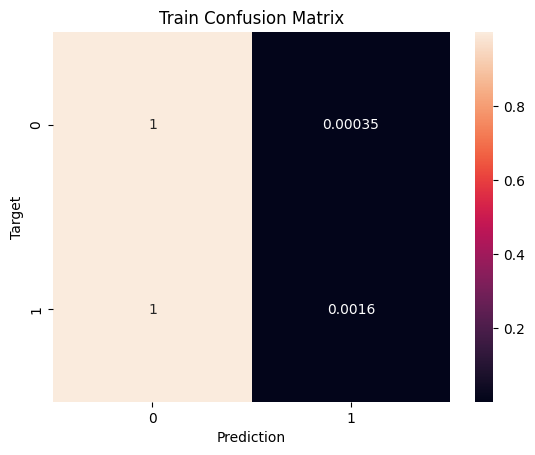

In [28]:
%%time
train_preds=predict_and_plot(train_inputs, train_targets,'Train')

Accuracy: 87.50%
CPU times: total: 188 ms
Wall time: 188 ms


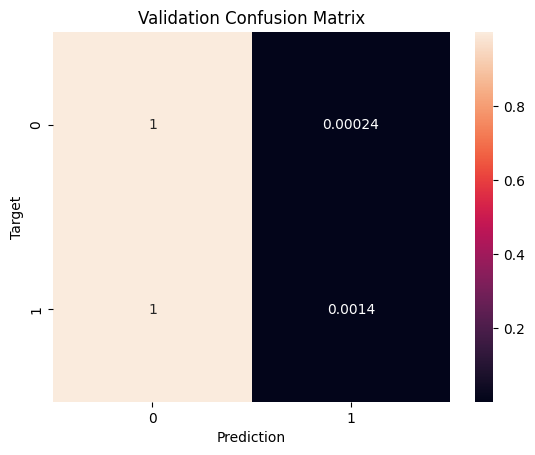

In [29]:
%%time
val_preds=predict_and_plot(val_inputs, val_targets,'Validation')

In [30]:
from sklearn.ensemble import RandomForestClassifier
model_2=RandomForestClassifier(n_jobs=-1, random_state=42)
model_2.fit(train_inputs, train_targets)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [31]:
%%time
model_2.score(train_inputs, train_targets)

CPU times: total: 26.3 s
Wall time: 7.56 s


0.9998622440445148

In [32]:
from sklearn.metrics import confusion_matrix
def predict_and_plot_2(inputs, targets,name=''):
    preds=model_2.predict(inputs)
    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))
    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name));    
    return preds

Accuracy: 86.50%
CPU times: total: 5.11 s
Wall time: 1.5 s


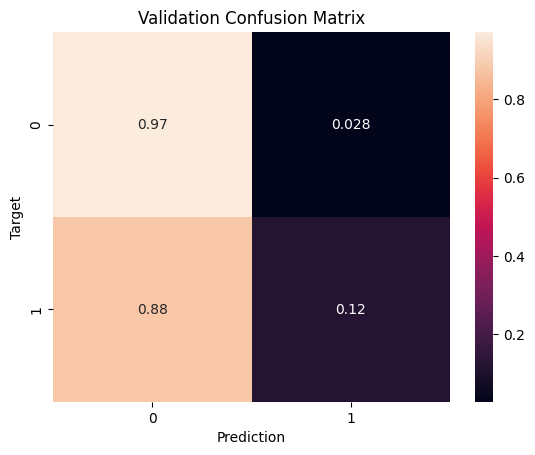

In [33]:
%%time
val_preds_2 = predict_and_plot_2(val_inputs, val_targets, 'Validation')

In [34]:
from sklearn.tree import DecisionTreeClassifier
model_3=DecisionTreeClassifier(random_state=42)
model_3.fit(train_inputs, train_targets)

DecisionTreeClassifier(random_state=42)

In [35]:
%%time
train_preds_3=model_3.predict(train_inputs)
train_probs_3=model_3.predict_proba(train_inputs)
accuracy_score(train_targets, train_preds_3)

CPU times: total: 500 ms
Wall time: 483 ms


0.9998852033704291

In [36]:
def predict_and_plot_3(inputs, targets, name=''):
    preds = model_3.predict(inputs)
    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))
    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name));    
    return preds

Accuracy: 86.50%
CPU times: total: 5.16 s
Wall time: 1.52 s


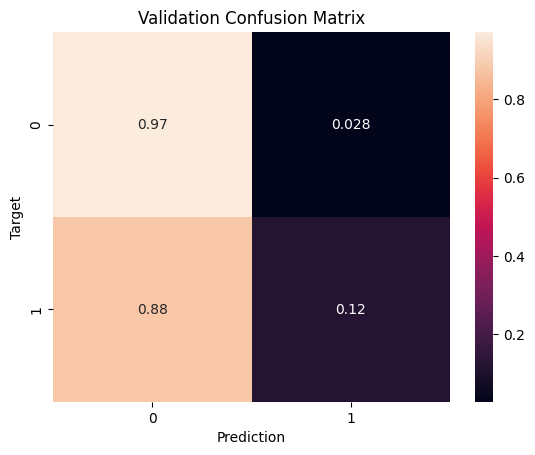

In [37]:
%%time
val_preds = predict_and_plot_2(val_inputs, val_targets, 'Validation')

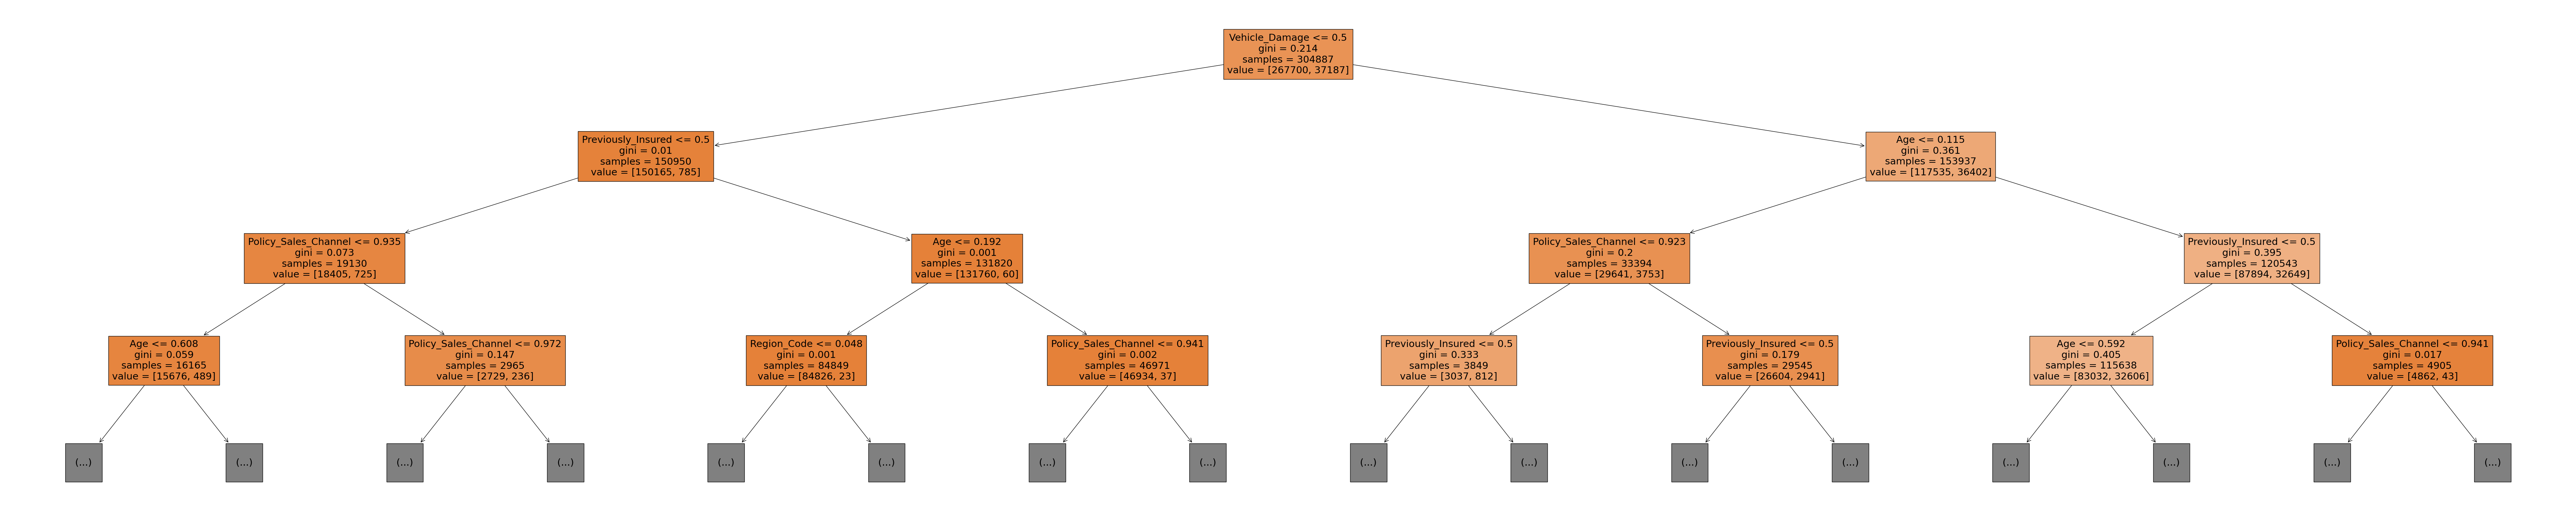

In [38]:
from sklearn.tree import plot_tree, export_text
plt.figure(figsize=(100,20))
plot_tree(model_3, feature_names=train_inputs.columns, max_depth=3, filled=True);

In [39]:
model_3_text=export_text(model_3, feature_names=list(train_inputs.columns))
print(model_3_text[:3000])

|--- Vehicle_Damage <= 0.50
|   |--- Previously_Insured <= 0.50
|   |   |--- Policy_Sales_Channel <= 0.94
|   |   |   |--- Age <= 0.61
|   |   |   |   |--- Policy_Sales_Channel <= 0.92
|   |   |   |   |   |--- Age <= 0.30
|   |   |   |   |   |   |--- Policy_Sales_Channel <= 0.75
|   |   |   |   |   |   |   |--- Region_Code <= 0.99
|   |   |   |   |   |   |   |   |--- Annual_Premium <= 0.20
|   |   |   |   |   |   |   |   |   |--- Age <= 0.05
|   |   |   |   |   |   |   |   |   |   |--- Vintage <= 0.90
|   |   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |   |   |--- Vintage >  0.90
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |--- Age >  0.05
|   |   |   |   |   |   |   |   |   |   |--- Vintage <= 0.71
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 16
|   |   |   |   |   |   |   |   |   |   |--- Vintage >  0.71
|   |   |   |   |   |   |   |   |   |   |   